In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import glob
import os

# Path to your Drive folder
data_path = '/content/drive/MyDrive/championship_data/'
all_files=glob.glob(os.path.join(data_path, '*.csv'))
print("All files found")
for i in all_files:
  print(i)

All files found
/content/drive/MyDrive/championship_data/16 17 .csv
/content/drive/MyDrive/championship_data/17 18.csv
/content/drive/MyDrive/championship_data/18 19.csv
/content/drive/MyDrive/championship_data/19 20.csv
/content/drive/MyDrive/championship_data/20 21.csv
/content/drive/MyDrive/championship_data/21 22.csv
/content/drive/MyDrive/championship_data/22 23.csv
/content/drive/MyDrive/championship_data/23 24.csv


In [3]:
dfs = []

for f in all_files:
    df = pd.read_csv(f, encoding='latin-1')
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

print(f"Total matches loaded: {len(combined_df)}")
print(f"Total columns: {len(combined_df.columns)}")
combined_df.head()

Total matches loaded: 4416
Total columns: 127


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E1,05/08/16,Fulham,Newcastle,1,0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E1,06/08/16,Birmingham,Cardiff,0,0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E1,06/08/16,Blackburn,Norwich,1,4,A,0.0,3.0,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E1,06/08/16,Bristol City,Wigan,2,1,H,0.0,1.0,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E1,06/08/16,Derby,Brighton,0,0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(combined_df.columns.tolist())

['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA', 'Time', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2

In [5]:
cols_to_keep = [
    # Match info
    'Date', 'HomeTeam', 'AwayTeam',

    # Result - this is what we predict
    'FTHG', 'FTAG', 'FTR',

    # Half time
    'HTHG', 'HTAG', 'HTR',

    # Match stats
    'HS', 'AS', 'HST', 'AST',
    'HC', 'AC', 'HF', 'AF',
    'HY', 'AY', 'HR', 'AR',

    # Average odds (most reliable)
    'AvgH', 'AvgD', 'AvgA',

    # Closing odds (final odds before kickoff)
    'AvgCH', 'AvgCD', 'AvgCA'
]

# Only keep columns that actually exist in our data
cols_to_keep = [c for c in cols_to_keep if c in combined_df.columns]

df = combined_df[cols_to_keep].copy()

print(f"Columns kept: {len(df.columns)}")
print(f"Columns removed: {len(combined_df.columns) - len(df.columns)}")
print(f"Total matches: {len(df)}")
df.head()

Columns kept: 27
Columns removed: 100
Total matches: 4416


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,...,HY,AY,HR,AR,AvgH,AvgD,AvgA,AvgCH,AvgCD,AvgCA
0,05/08/16,Fulham,Newcastle,1,0,H,1.0,0.0,H,5.0,...,1.0,3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,06/08/16,Birmingham,Cardiff,0,0,D,0.0,0.0,D,14.0,...,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,06/08/16,Blackburn,Norwich,1,4,A,0.0,3.0,A,5.0,...,1.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,06/08/16,Bristol City,Wigan,2,1,H,0.0,1.0,A,24.0,...,1.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,06/08/16,Derby,Brighton,0,0,D,0.0,0.0,D,12.0,...,2.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Fix date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort matches oldest to newest
df = df.sort_values('Date').reset_index(drop=True)

# Check missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent
})

print("Missing values per column:")
print(missing_report[missing_report['Missing Count'] > 0])

print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total matches: {len(df)}")

Missing values per column:
       Missing Count  Missing Percent
HTHG               1         0.022645
HTAG               1         0.022645
HTR                1         0.022645
HS                 1         0.022645
AS                 1         0.022645
HST                1         0.022645
AST                1         0.022645
HC                 1         0.022645
AC                 1         0.022645
HF                 1         0.022645
AF                 1         0.022645
HY                 1         0.022645
AY                 1         0.022645
HR                 1         0.022645
AR                 1         0.022645
AvgH            1656        37.500000
AvgD            1656        37.500000
AvgA            1656        37.500000
AvgCH           1656        37.500000
AvgCD           1656        37.500000
AvgCA           1656        37.500000

Date range: 2016-08-05 00:00:00 to 2024-05-04 00:00:00
Total matches: 4416


/tmp/ipykernel_6167/597595085.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [7]:
# Drop the 1 match with missing stats
df = df.dropna(subset=['FTHG', 'FTAG', 'FTR', 'HS'])

# Drop odds columns since 37.5% is too much missing data
df = df.drop(columns=['AvgH', 'AvgD', 'AvgA', 'AvgCH', 'AvgCD', 'AvgCA'])

print(f"Total matches after cleaning: {len(df)}")
print(f"Remaining columns: {df.columns.tolist()}")
print(f"Any missing values left: {df.isnull().sum().sum()}")


Total matches after cleaning: 4415
Remaining columns: ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']
Any missing values left: 0


In [8]:
# Function to calculate points earned by home and away team
def get_points(result):
    if result == 'H':
        return 3, 0   # Home wins = 3 points, Away gets 0
    elif result == 'A':
        return 0, 3   # Away wins = 3 points, Home gets 0
    else:
        return 1, 1   # Draw = 1 point each

# Apply this to every match
df['HomePoints'] = df['FTR'].apply(lambda x: get_points(x)[0])
df['AwayPoints'] = df['FTR'].apply(lambda x: get_points(x)[1])

print(df[['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'HomePoints', 'AwayPoints']].head(10))

        Date       HomeTeam   AwayTeam FTR  HomePoints  AwayPoints
0 2016-08-05         Fulham  Newcastle   H           3           0
1 2016-08-06      Rotherham     Wolves   D           1           1
2 2016-08-06  Nott'm Forest     Burton   H           3           0
3 2016-08-06        Ipswich   Barnsley   H           3           0
4 2016-08-06   Huddersfield  Brentford   H           3           0
5 2016-08-06        Reading    Preston   H           3           0
6 2016-08-06   Bristol City      Wigan   H           3           0
7 2016-08-06      Blackburn    Norwich   A           0           3
8 2016-08-06     Birmingham    Cardiff   D           1           1
9 2016-08-06          Derby   Brighton   D           1           1


In [9]:
# Sort by date to make sure everything is in order
df = df.sort_values('Date').reset_index(drop=True)

# Create a combined match list for each team
# (each team appears twice per matchday - once home once away)

def get_team_form(df, team, date, n=5):
    # Get all matches this team played BEFORE this date
    team_matches = df[
        ((df['HomeTeam'] == team) | (df['AwayTeam'] == team)) &
        (df['Date'] < date)
    ].tail(n)  # last n matches

    if len(team_matches) == 0:
        return 0, 0, 0  # no history yet

    points = 0
    scored = 0
    conceded = 0

    for _, match in team_matches.iterrows():
        if match['HomeTeam'] == team:
            points += match['HomePoints']
            scored += match['FTHG']
            conceded += match['FTAG']
        else:
            points += match['AwayPoints']
            scored += match['FTAG']
            conceded += match['FTHG']

    return points, scored, conceded

print("Form function created successfully!")
print("Testing on first match...")

# Quick test
test_date = df['Date'].iloc[50]
test_team = df['HomeTeam'].iloc[50]
pts, scored, conceded = get_team_form(df, test_team, test_date)
print(f"Team: {test_team}")
print(f"Last 5 matches before {test_date.date()}: {pts} points, {scored} scored, {conceded} conceded")

Form function created successfully!
Testing on first match...
Team: Barnsley
Last 5 matches before 2016-08-27: 6 points, 8 scored, 8 conceded


In [10]:
from tqdm.notebook import tqdm  # progress bar so we can see it working

# Create empty lists to store results
home_form_pts, home_form_scored, home_form_conceded = [], [], []
away_form_pts, away_form_scored, away_form_conceded = [], [], []

print("Calculating form for all matches... this will take a minute!")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    # Home team form
    h_pts, h_scored, h_conceded = get_team_form(df, row['HomeTeam'], row['Date'])
    home_form_pts.append(h_pts)
    home_form_scored.append(h_scored)
    home_form_conceded.append(h_conceded)

    # Away team form
    a_pts, a_scored, a_conceded = get_team_form(df, row['AwayTeam'], row['Date'])
    away_form_pts.append(a_pts)
    away_form_scored.append(a_scored)
    away_form_conceded.append(a_conceded)

# Add all as new columns
df['HomeFormPts'] = home_form_pts
df['HomeFormScored'] = home_form_scored
df['HomeFormConceded'] = home_form_conceded
df['AwayFormPts'] = away_form_pts
df['AwayFormScored'] = away_form_scored
df['AwayFormConceded'] = away_form_conceded

print("Done!")
print(df[['Date', 'HomeTeam', 'AwayTeam', 'FTR',
          'HomeFormPts', 'HomeFormScored', 'HomeFormConceded',
          'AwayFormPts', 'AwayFormScored', 'AwayFormConceded']].head(10))

Calculating form for all matches... this will take a minute!


  0%|          | 0/4415 [00:00<?, ?it/s]

Done!
        Date       HomeTeam   AwayTeam FTR  HomeFormPts  HomeFormScored  \
0 2016-08-05         Fulham  Newcastle   H            0               0   
1 2016-08-06          Derby   Brighton   D            0               0   
2 2016-08-06      Blackburn    Norwich   A            0               0   
3 2016-08-06   Bristol City      Wigan   H            0               0   
4 2016-08-06        Reading    Preston   H            0               0   
5 2016-08-06     Birmingham    Cardiff   D            0               0   
6 2016-08-06        Ipswich   Barnsley   H            0               0   
7 2016-08-06  Nott'm Forest     Burton   H            0               0   
8 2016-08-06      Rotherham     Wolves   D            0               0   
9 2016-08-06   Huddersfield  Brentford   H            0               0   

   HomeFormConceded  AwayFormPts  AwayFormScored  AwayFormConceded  
0                 0            0               0                 0  
1                 0           

In [11]:
print(df[['Date', 'HomeTeam', 'AwayTeam', 'FTR',
          'HomeFormPts', 'HomeFormScored', 'HomeFormConceded',
          'AwayFormPts', 'AwayFormScored', 'AwayFormConceded']].iloc[45:55])

         Date        HomeTeam        AwayTeam FTR  HomeFormPts  \
45 2016-08-20       Blackburn          Burton   D            0   
46 2016-08-20  Sheffield Weds           Leeds   A            4   
47 2016-08-21         Ipswich         Norwich   D            4   
48 2016-08-26          Burton           Derby   H            4   
49 2016-08-27    Bristol City     Aston Villa   H            6   
50 2016-08-27        Barnsley       Rotherham   H            6   
51 2016-08-27      Birmingham         Norwich   H            5   
52 2016-08-27       Brentford  Sheffield Weds   D            6   
53 2016-08-27         Ipswich         Preston   H            5   
54 2016-08-27       Blackburn          Fulham   A            1   

    HomeFormScored  HomeFormConceded  AwayFormPts  AwayFormScored  \
45               2                 9            3               7   
46               2                 3            1               2   
47               4                 4            7               5 

In [12]:
# Goal difference from last 5 matches
df['HomeFormGD'] = df['HomeFormScored'] - df['HomeFormConceded']
df['AwayFormGD'] = df['AwayFormScored'] - df['AwayFormConceded']

print(df[['HomeTeam', 'AwayTeam', 'FTR', 'HomeFormGD', 'AwayFormGD']].iloc[45:55])

          HomeTeam        AwayTeam FTR  HomeFormGD  AwayFormGD
45       Blackburn          Burton   D          -7           0
46  Sheffield Weds           Leeds   A          -1          -4
47         Ipswich         Norwich   D           0           4
48          Burton           Derby   H           0          -1
49    Bristol City     Aston Villa   H           0           2
50        Barnsley       Rotherham   H           0          -5
51      Birmingham         Norwich   H          -1           4
52       Brentford  Sheffield Weds   D           1          -3
53         Ipswich         Preston   H           0          -1
54       Blackburn          Fulham   A          -7           2


In [13]:
# Encode our target variable FTR into numbers
# ML models need numbers not letters
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Target'] = le.fit_transform(df['FTR'])

print("Target encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df['Target'].value_counts())

Target encoding:
{'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}
Target
2    1916
0    1354
1    1145
Name: count, dtype: int64


In [14]:
# Select only the feature columns we'll feed into the model
feature_cols = [
    'HomeFormPts', 'HomeFormScored', 'HomeFormConceded', 'HomeFormGD',
    'AwayFormPts', 'AwayFormScored', 'AwayFormConceded', 'AwayFormGD'
]

X = df[feature_cols]
y = df['Target']

# Split into training and testing
# Training = 2016/17 to 2023/24
# Testing  = 2024/25 (which we'll load separately later)
# For now split last 20% as temporary test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Features: {feature_cols}")

Training samples: 3532
Testing samples: 883
Features: ['HomeFormPts', 'HomeFormScored', 'HomeFormConceded', 'HomeFormGD', 'AwayFormPts', 'AwayFormScored', 'AwayFormConceded', 'AwayFormGD']


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create and train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Away Win', 'Draw', 'Home Win']))

Logistic Regression Accuracy: 45.30%

Detailed Report:
              precision    recall  f1-score   support

    Away Win       0.41      0.26      0.32       284
        Draw       0.00      0.00      0.00       221
    Home Win       0.46      0.87      0.60       378

    accuracy                           0.45       883
   macro avg       0.29      0.37      0.31       883
weighted avg       0.33      0.45      0.36       883



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")
print(f"Improvement: {(xgb_accuracy - lr_accuracy):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Away Win', 'Draw', 'Home Win']))

XGBoost Accuracy: 44.39%
Logistic Regression Accuracy: 45.30%
Improvement: -0.91%

Detailed Report:
              precision    recall  f1-score   support

    Away Win       0.41      0.23      0.29       284
        Draw       0.32      0.05      0.09       221
    Home Win       0.46      0.84      0.59       378

    accuracy                           0.44       883
   macro avg       0.39      0.37      0.33       883
weighted avg       0.41      0.44      0.37       883



In [17]:
def get_team_stats(df, team, date, n=5):
    # Get last n matches before this date
    team_matches = df[
        ((df['HomeTeam'] == team) | (df['AwayTeam'] == team)) &
        (df['Date'] < date)
    ].tail(n)

    if len(team_matches) == 0:
        return 0, 0, 0, 0, 0, 0  # no history yet

    shots, shots_target, corners, fouls, yellows, ht_goals = 0, 0, 0, 0, 0, 0

    for _, match in team_matches.iterrows():
        if match['HomeTeam'] == team:
            shots += match['HS']
            shots_target += match['HST']
            corners += match['HC']
            fouls += match['HF']
            yellows += match['HY']
            ht_goals += match['HTHG']
        else:
            shots += match['AS']
            shots_target += match['AST']
            corners += match['AC']
            fouls += match['AF']
            yellows += match['AY']
            ht_goals += match['HTAG']

    # Return averages per game
    n_matches = len(team_matches)
    return (
        shots / n_matches,
        shots_target / n_matches,
        corners / n_matches,
        fouls / n_matches,
        yellows / n_matches,
        ht_goals / n_matches
    )

print("Stats function created!")

# Test it
test_date = df['Date'].iloc[100]
test_team = df['HomeTeam'].iloc[100]
shots, sot, corners, fouls, yellows, ht = get_team_stats(df, test_team, test_date)
print(f"\nTeam: {test_team}")
print(f"Before: {test_date.date()}")
print(f"Avg Shots: {shots:.1f}")
print(f"Avg Shots on Target: {sot:.1f}")
print(f"Avg Corners: {corners:.1f}")
print(f"Avg Fouls: {fouls:.1f}")
print(f"Avg Yellows: {yellows:.1f}")
print(f"Avg HT Goals: {ht:.1f}")

Stats function created!

Team: Brighton
Before: 2016-09-24
Avg Shots: 14.4
Avg Shots on Target: 3.8
Avg Corners: 5.6
Avg Fouls: 12.2
Avg Yellows: 2.2
Avg HT Goals: 0.2


In [18]:
from tqdm.notebook import tqdm

# Empty lists for home team stats
home_shots, home_sot, home_corners = [], [], []
home_fouls, home_yellows, home_ht_goals = [], [], []

# Empty lists for away team stats
away_shots, away_sot, away_corners = [], [], []
away_fouls, away_yellows, away_ht_goals = [], [], []

print("Calculating match stats for all matches... wait a moment!")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    # Home team stats
    h_shots, h_sot, h_corners, h_fouls, h_yellows, h_ht = get_team_stats(
        df, row['HomeTeam'], row['Date']
    )
    home_shots.append(h_shots)
    home_sot.append(h_sot)
    home_corners.append(h_corners)
    home_fouls.append(h_fouls)
    home_yellows.append(h_yellows)
    home_ht_goals.append(h_ht)

    # Away team stats
    a_shots, a_sot, a_corners, a_fouls, a_yellows, a_ht = get_team_stats(
        df, row['AwayTeam'], row['Date']
    )
    away_shots.append(a_shots)
    away_sot.append(a_sot)
    away_corners.append(a_corners)
    away_fouls.append(a_fouls)
    away_yellows.append(a_yellows)
    away_ht_goals.append(a_ht)

# Add as new columns
df['HomeAvgShots'] = home_shots
df['HomeAvgSOT'] = home_sot
df['HomeAvgCorners'] = home_corners
df['HomeAvgFouls'] = home_fouls
df['HomeAvgYellows'] = home_yellows
df['HomeAvgHTGoals'] = home_ht_goals

df['AwayAvgShots'] = away_shots
df['AwayAvgSOT'] = away_sot
df['AwayAvgCorners'] = away_corners
df['AwayAvgFouls'] = away_fouls
df['AwayAvgYellows'] = away_yellows
df['AwayAvgHTGoals'] = away_ht_goals

print("Done!")
print(f"Total features now: {len(df.columns)}")
print(df[['HomeTeam', 'AwayTeam', 'HomeAvgShots', 'HomeAvgSOT',
          'AwayAvgShots', 'AwayAvgSOT']].iloc[45:50])

Calculating match stats for all matches... wait a moment!


  0%|          | 0/4415 [00:00<?, ?it/s]

Done!
Total features now: 44
          HomeTeam     AwayTeam  HomeAvgShots  HomeAvgSOT  AwayAvgShots  \
45       Blackburn       Burton      7.666667    2.333333     16.666667   
46  Sheffield Weds        Leeds     10.666667    4.666667     11.333333   
47         Ipswich      Norwich     11.333333    4.000000     11.000000   
48          Burton        Derby     16.000000    4.750000     13.750000   
49    Bristol City  Aston Villa     14.750000    3.500000     13.750000   

    AwayAvgSOT  
45    5.333333  
46    2.333333  
47    4.666667  
48    3.250000  
49    4.500000  


In [19]:
def get_attack_defence_strength(df, team, date, n=5):
    team_matches = df[
        ((df['HomeTeam'] == team) | (df['AwayTeam'] == team)) &
        (df['Date'] < date)
    ].tail(n)

    if len(team_matches) == 0:
        return 0, 0

    goals_scored = 0
    goals_conceded = 0

    for _, match in team_matches.iterrows():
        if match['HomeTeam'] == team:
            goals_scored += match['FTHG']
            goals_conceded += match['FTAG']
        else:
            goals_scored += match['FTAG']
            goals_conceded += match['FTHG']

    n_matches = len(team_matches)
    return goals_scored / n_matches, goals_conceded / n_matches

# Apply to all matches
home_attack, home_defence = [], []
away_attack, away_defence = [], []

print("Calculating attack and defence strength...")

from tqdm.notebook import tqdm

for idx, row in tqdm(df.iterrows(), total=len(df)):
    h_att, h_def = get_attack_defence_strength(df, row['HomeTeam'], row['Date'])
    home_attack.append(h_att)
    home_defence.append(h_def)

    a_att, a_def = get_attack_defence_strength(df, row['AwayTeam'], row['Date'])
    away_attack.append(a_att)
    away_defence.append(a_def)

df['HomeAttackStrength'] = home_attack
df['HomeDefenceStrength'] = home_defence
df['AwayAttackStrength'] = away_attack
df['AwayDefenceStrength'] = away_defence

print("Done!")
print(df[['HomeTeam', 'AwayTeam', 'FTR',
          'HomeAttackStrength', 'HomeDefenceStrength',
          'AwayAttackStrength', 'AwayDefenceStrength']].iloc[45:50])

Calculating attack and defence strength...


  0%|          | 0/4415 [00:00<?, ?it/s]

Done!
          HomeTeam     AwayTeam FTR  HomeAttackStrength  HomeDefenceStrength  \
45       Blackburn       Burton   D            0.666667             3.000000   
46  Sheffield Weds        Leeds   A            0.666667             1.000000   
47         Ipswich      Norwich   D            1.333333             1.333333   
48          Burton        Derby   H            2.250000             2.250000   
49    Bristol City  Aston Villa   H            1.000000             1.000000   

    AwayAttackStrength  AwayDefenceStrength  
45            2.333333             2.333333  
46            0.666667             2.000000  
47            1.666667             0.333333  
48            0.250000             0.500000  
49            1.000000             0.500000  


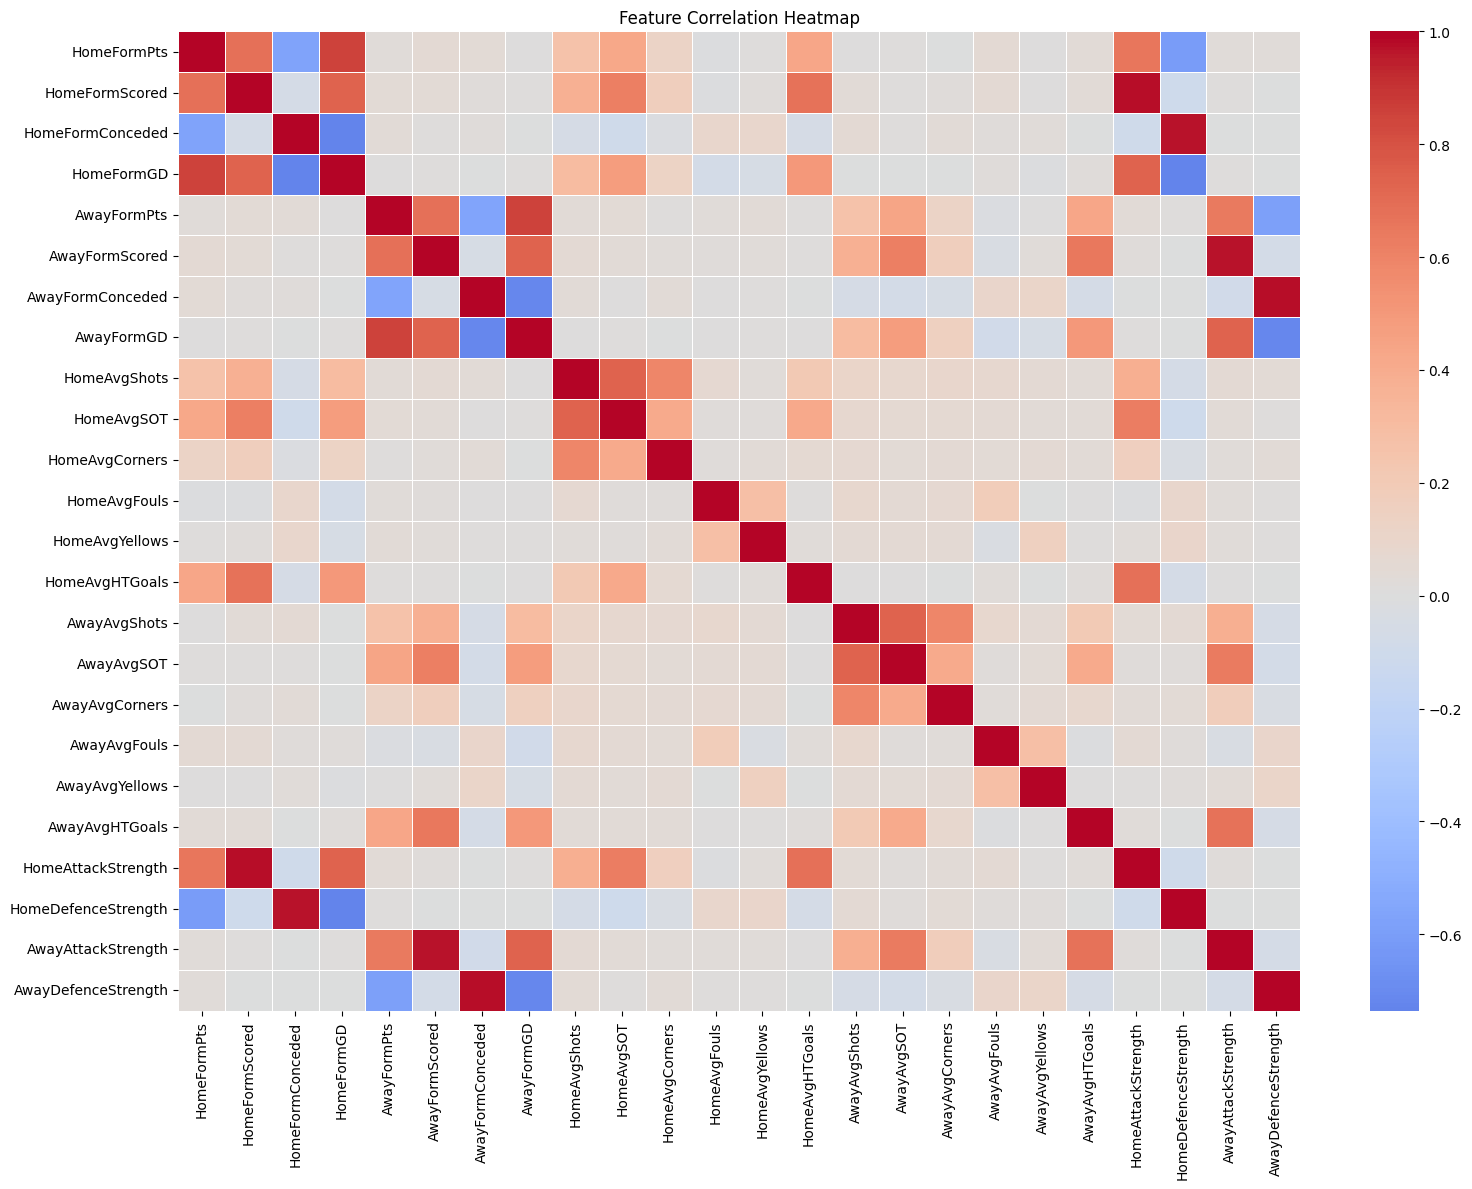


Highly correlated feature pairs (>0.85):
HomeFormPts vs HomeFormGD: 0.85
HomeFormScored vs HomeAttackStrength: 0.98
HomeFormConceded vs HomeDefenceStrength: 0.97
AwayFormPts vs AwayFormGD: 0.86
AwayFormScored vs AwayAttackStrength: 0.97
AwayFormConceded vs AwayDefenceStrength: 0.97


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only our feature columns
feature_cols = [
    'HomeFormPts', 'HomeFormScored', 'HomeFormConceded', 'HomeFormGD',
    'AwayFormPts', 'AwayFormScored', 'AwayFormConceded', 'AwayFormGD',
    'HomeAvgShots', 'HomeAvgSOT', 'HomeAvgCorners', 'HomeAvgFouls',
    'HomeAvgYellows', 'HomeAvgHTGoals',
    'AwayAvgShots', 'AwayAvgSOT', 'AwayAvgCorners', 'AwayAvgFouls',
    'AwayAvgYellows', 'AwayAvgHTGoals',
    'HomeAttackStrength', 'HomeDefenceStrength',
    'AwayAttackStrength', 'AwayDefenceStrength'
]

# Calculate correlation matrix
corr_matrix = df[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print highly correlated pairs (above 0.85)
print("\nHighly correlated feature pairs (>0.85):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")

In [21]:
# Drop highly correlated redundant features
cols_to_drop = [
    'HomeAttackStrength', 'HomeDefenceStrength',
    'AwayAttackStrength', 'AwayDefenceStrength'
]

df = df.drop(columns=cols_to_drop)

print(f"Features remaining: {len(df.columns)}")
print("Dropped:", cols_to_drop)

Features remaining: 44
Dropped: ['HomeAttackStrength', 'HomeDefenceStrength', 'AwayAttackStrength', 'AwayDefenceStrength']


In [22]:
print(f"Total columns: {len(df.columns)}")
print(df.columns.tolist())

Total columns: 44
['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'HomePoints', 'AwayPoints', 'HomeFormPts', 'HomeFormScored', 'HomeFormConceded', 'AwayFormPts', 'AwayFormScored', 'AwayFormConceded', 'HomeFormGD', 'AwayFormGD', 'Target', 'HomeAvgShots', 'HomeAvgSOT', 'HomeAvgCorners', 'HomeAvgFouls', 'HomeAvgYellows', 'HomeAvgHTGoals', 'AwayAvgShots', 'AwayAvgSOT', 'AwayAvgCorners', 'AwayAvgFouls', 'AwayAvgYellows', 'AwayAvgHTGoals']


In [23]:
df.to_csv('/content/drive/MyDrive/championship_data/cleaned_df.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [25]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

feature_cols = [
    'HomeFormPts', 'HomeFormScored', 'HomeFormConceded', 'HomeFormGD',
    'AwayFormPts', 'AwayFormScored', 'AwayFormConceded', 'AwayFormGD',
    'HomeAvgShots', 'HomeAvgSOT', 'HomeAvgCorners',
    'HomeAvgFouls', 'HomeAvgYellows', 'HomeAvgHTGoals',
    'AwayAvgShots', 'AwayAvgSOT', 'AwayAvgCorners',
    'AwayAvgFouls', 'AwayAvgYellows', 'AwayAvgHTGoals'
]

X = df[feature_cols]
y = df['Target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rfecv = RFECV(
    estimator=rf,
    step=1,
    cv=StratifiedKFold(10),
    scoring='accuracy',
    n_jobs=-1
)

print("Running Backward Wrapper Selection...")
print("This will take a few minutes!")
rfecv.fit(X, y)

print(f"\nOptimal number of features: {rfecv.n_features_}")
print(f"\nSelected features:")
selected_features = [f for f, s in zip(feature_cols, rfecv.support_) if s]
removed_features = [f for f, s in zip(feature_cols, rfecv.support_) if not s]
for f in selected_features:
    print(f"  ✅ {f}")
print(f"\nRemoved features:")
for f in removed_features:
    print(f"  ❌ {f}")

Running Backward Wrapper Selection...
This will take a few minutes!

Optimal number of features: 20

Selected features:
  ✅ HomeFormPts
  ✅ HomeFormScored
  ✅ HomeFormConceded
  ✅ HomeFormGD
  ✅ AwayFormPts
  ✅ AwayFormScored
  ✅ AwayFormConceded
  ✅ AwayFormGD
  ✅ HomeAvgShots
  ✅ HomeAvgSOT
  ✅ HomeAvgCorners
  ✅ HomeAvgFouls
  ✅ HomeAvgYellows
  ✅ HomeAvgHTGoals
  ✅ AwayAvgShots
  ✅ AwayAvgSOT
  ✅ AwayAvgCorners
  ✅ AwayAvgFouls
  ✅ AwayAvgYellows
  ✅ AwayAvgHTGoals

Removed features:


In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Use all 20 selected features
X = df[selected_features]
y = df['Target']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy (8 features): 44.39%")
print(f"XGBoost Accuracy (20 features): {xgb_accuracy:.2%}")
print(f"Improvement: {(xgb_accuracy - 0.4439):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Away Win', 'Draw', 'Home Win']))

XGBoost Accuracy (8 features): 44.39%
XGBoost Accuracy (20 features): 44.17%
Improvement: -0.22%

Detailed Report:
              precision    recall  f1-score   support

    Away Win       0.41      0.29      0.34       284
        Draw       0.26      0.05      0.08       221
    Home Win       0.46      0.79      0.58       378

    accuracy                           0.44       883
   macro avg       0.38      0.37      0.33       883
weighted avg       0.39      0.44      0.38       883



In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

X = df[selected_features]
y = df['Target']

# XGBoost with better parameters
xgb_model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    eval_metric='mlogloss',
    scale_pos_weight=1
)

# 10 fold cross validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Running 10-fold cross validation...")
scores = cross_val_score(
    xgb_model_v2, X, y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\nCV Scores per fold:")
for i, s in enumerate(scores):
    print(f"  Fold {i+1}: {s:.2%}")
print(f"\nMean Accuracy: {scores.mean():.2%}")
print(f"Std Deviation: {scores.std():.2%}")

Running 10-fold cross validation...

CV Scores per fold:
  Fold 1: 44.57%
  Fold 2: 41.40%
  Fold 3: 44.12%
  Fold 4: 44.80%
  Fold 5: 44.12%
  Fold 6: 45.80%
  Fold 7: 44.22%
  Fold 8: 46.26%
  Fold 9: 43.31%
  Fold 10: 44.22%

Mean Accuracy: 44.28%
Std Deviation: 1.26%


In [29]:
# Elo Rating Implementation

def calculate_elo(df, k=32, base_rating=1500):
    # Give every team a starting rating of 1500
    elo_ratings = {}

    # Store each team's elo BEFORE each match
    home_elos = []
    away_elos = []

    for idx, row in df.iterrows():
        home_team = row['HomeTeam']
        away_team = row['AwayTeam']
        result = row['FTR']

        # If team not seen before give them base rating
        if home_team not in elo_ratings:
            elo_ratings[home_team] = base_rating
        if away_team not in elo_ratings:
            elo_ratings[away_team] = base_rating

        # Get current ratings BEFORE match
        home_elo = elo_ratings[home_team]
        away_elo = elo_ratings[away_team]

        # Store pre match ratings
        home_elos.append(home_elo)
        away_elos.append(away_elo)

        # Calculate expected outcome
        expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
        expected_away = 1 - expected_home

        # Actual outcome
        if result == 'H':
            actual_home = 1
            actual_away = 0
        elif result == 'A':
            actual_home = 0
            actual_away = 1
        else:  # Draw
            actual_home = 0.5
            actual_away = 0.5

        # Update ratings AFTER match
        elo_ratings[home_team] += k * (actual_home - expected_home)
        elo_ratings[away_team] += k * (actual_away - expected_away)

    return home_elos, away_elos

print("Calculating Elo ratings for all matches...")
home_elos, away_elos = calculate_elo(df)

df['HomeElo'] = home_elos
df['AwayElo'] = away_elos
df['EloDiff'] = df['HomeElo'] - df['AwayElo']

print("Done!")
print(df[['HomeTeam', 'AwayTeam', 'FTR',
          'HomeElo', 'AwayElo', 'EloDiff']].iloc[100:105])

Calculating Elo ratings for all matches...
Done!
           HomeTeam       AwayTeam FTR      HomeElo      AwayElo    EloDiff
100        Brighton       Barnsley   H  1530.180426  1529.196393   0.984033
101           Leeds        Ipswich   H  1491.352017  1512.354400 -21.002382
102  Sheffield Weds  Nott'm Forest   H  1498.425623  1497.709150   0.716473
103             QPR     Birmingham   D  1479.499382  1547.589963 -68.090581
104       Rotherham        Cardiff   A  1457.385316  1437.743257  19.642059


In [30]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Add Elo to our feature set
selected_features_v2 = selected_features + ['HomeElo', 'AwayElo', 'EloDiff']

X = df[selected_features_v2]
y = df['Target']

xgb_model_v3 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    eval_metric='mlogloss'
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Running 10-fold CV with Elo features...")
scores = cross_val_score(
    xgb_model_v3, X, y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\nCV Scores per fold:")
for i, s in enumerate(scores):
    print(f"  Fold {i+1}: {s:.2%}")
print(f"\nPrevious Mean Accuracy: 44.28%")
print(f"New Mean Accuracy:      {scores.mean():.2%}")
print(f"Improvement:            {(scores.mean() - 0.4428):.2%}")

Running 10-fold CV with Elo features...

CV Scores per fold:
  Fold 1: 45.70%
  Fold 2: 42.99%
  Fold 3: 42.31%
  Fold 4: 46.15%
  Fold 5: 44.80%
  Fold 6: 45.12%
  Fold 7: 45.35%
  Fold 8: 40.82%
  Fold 9: 41.95%
  Fold 10: 45.12%

Previous Mean Accuracy: 44.28%
New Mean Accuracy:      44.03%
Improvement:            -0.25%
